# 02 — Weight of Evidence (WoE) Binning

Transform continuous features into WoE values — the standard approach
in credit risk modelling under Basel II/III frameworks.

Outputs:
- WoE-transformed feature matrix
- Information Value (IV) ranking for feature selection
- Bin boundary documentation

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from woe_encoder import WoEEncoder

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/train_features.csv")
target = "TARGET"
exclude = ["SK_ID_CURR", "SK_ID_PREV", target]

numeric_cols = df.select_dtypes(include="number").columns.drop(exclude, errors="ignore").tolist()
X = df[numeric_cols]
y = df[target]

print(f"Features: {len(numeric_cols)} | Rows: {len(df):,}")

Features: 181 | Rows: 307,511


## Fit WoE Encoder

In [3]:
encoder = WoEEncoder(bins=10, min_bin_size=0.05)
X_woe = encoder.fit_transform(X, y)

print("WoE transformation complete.")
X_woe.head()

c:\Users\Eric\credit-scorecard-project\notebooks\../src\woe_encoder.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("bin")["y"].agg(events="sum", total="count")
c:\Users\Eric\credit-scorecard-project\notebooks\../src\woe_encoder.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("bin")["y"].agg(events="sum", total="count")
c:\Users\Eric\credit-scorecard-project\notebooks\../src\woe_encoder.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

WoE transformation complete.


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,revolving_loans,latest_decision_days,earliest_decision_days,LOAN_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,AGE_YEARS,EMPLOYMENT_YEARS,EXT_SOURCE_MEAN,EXT_SOURCE_STD
0,0.012642,0.036358,-0.239090,-0.053119,-0.241814,-0.172132,-0.399803,-0.371429,-0.081118,-0.114963,...,0.053599,0.099412,-0.250986,-0.005532,0.034516,-0.071310,-0.398773,-0.370131,-1.220363,0.183974
1,0.012642,0.147763,0.444701,-0.068874,0.530594,-0.065684,0.038263,-0.288526,-0.124323,-0.253847,...,0.053599,0.129505,0.170878,0.016393,0.030975,0.262875,0.037917,-0.288577,-0.005785,-0.114629
2,0.012642,-0.015918,0.197529,0.138066,0.110946,0.048464,0.260101,-0.370257,-0.081118,-0.114963,...,0.053599,0.129505,-0.199270,-0.005532,0.116271,0.170966,0.259589,-0.369823,0.816340,0.161987
3,0.012642,-0.054925,-0.239090,-0.244344,-0.241814,-0.155306,0.260101,0.125730,0.213334,-0.114963,...,-0.273102,-0.097393,-0.199270,-0.121525,-0.101067,0.626190,0.259589,0.125134,1.071454,NaN
4,0.012642,-0.054925,-0.188886,-0.080274,0.226612,0.083847,0.260101,0.125730,-0.081118,0.039737,...,0.053599,0.071043,0.170878,-0.071267,-0.039999,0.288003,0.259589,0.125134,-0.659378,NaN


## Information Value Summary

IV interpretation (industry standard):
- < 0.02 → Useless
- 0.02–0.1 → Weak
- 0.1–0.3 → Medium
- 0.3–0.5 → Strong
- > 0.5 → Suspicious (possible info leakage)

In [4]:
iv_summary = encoder.get_iv_summary()
print(f"Features by predictive power:\n")
print(iv_summary.groupby("Predictive_Power").size().to_string())
print(f"\nTop 20 features by IV:\n")
iv_summary.head(20)

Features by predictive power:

Predictive_Power
Medium          7
Strong          3
Suspicious      1
Useless       108
Weak           62

Top 20 features by IV:



,IV,Predictive_Power
EXT_SOURCE_MEAN,0.608452,Suspicious
EXT_SOURCE_3,0.409969,Strong
EXT_SOURCE_1,0.346257,Strong
EXT_SOURCE_2,0.307030,Strong
avg_utilisation_ratio,0.232423,Medium
avg_drawing_count,0.196534,Medium
avg_drawings,0.152915,Medium
avg_cc_balance,0.150532,Medium
debt_to_credit_ratio,0.111454,Medium
DAYS_EMPLOYED,0.101246,Medium


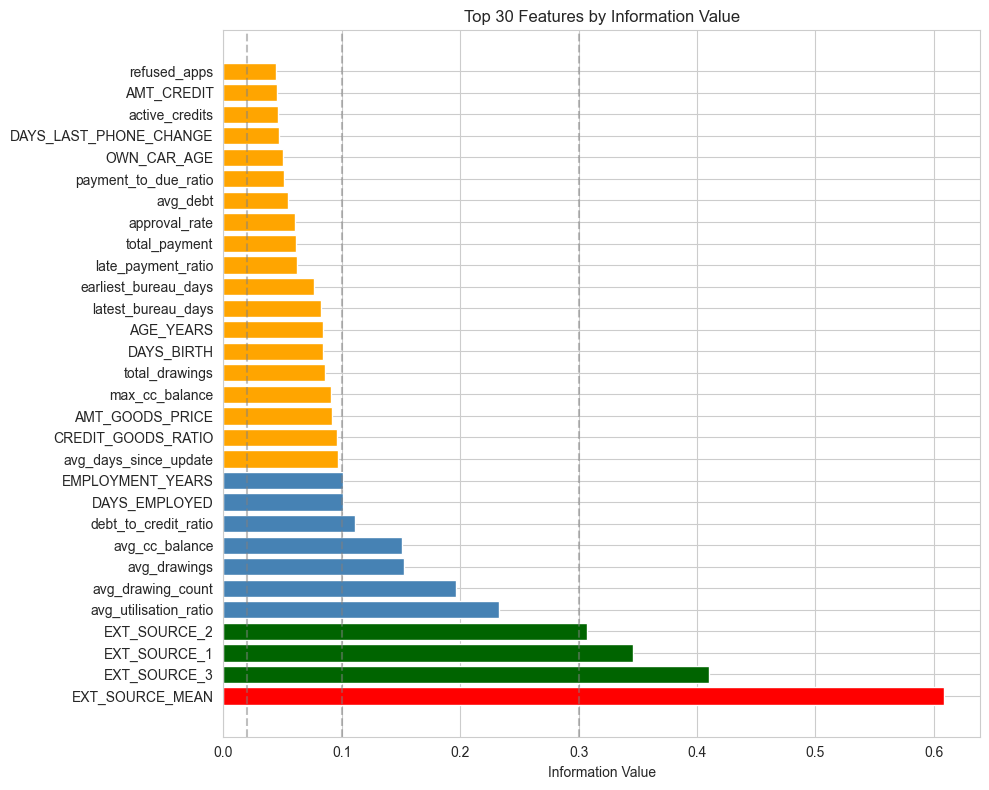

In [5]:
# IV bar chart — top 30
fig, ax = plt.subplots(figsize=(10, 8))
top_iv = iv_summary.head(30)
colors = top_iv["Predictive_Power"].map({
    "Strong": "darkgreen", "Medium": "steelblue",
    "Weak": "orange", "Useless": "lightgray", "Suspicious": "red"
})
ax.barh(top_iv.index, top_iv["IV"], color=colors)
ax.set_xlabel("Information Value")
ax.set_title("Top 30 Features by Information Value")
ax.axvline(x=0.02, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0.1, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0.3, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Feature Selection Based on IV

Select features with IV ≥ 0.02 (discard "Useless" variables).

In [6]:
selected_features = iv_summary[iv_summary["IV"] >= 0.02].index.tolist()
print(f"Selected {len(selected_features)} of {len(numeric_cols)} features (IV ≥ 0.02)")

# Save for downstream notebooks
X_woe_selected = X_woe[selected_features]
X_woe_selected.to_csv("../data/processed/X_woe.csv", index=False)
iv_summary.to_csv("../data/processed/iv_summary.csv")
print("✓ Saved X_woe.csv and iv_summary.csv")

Selected 73 of 181 features (IV ≥ 0.02)
✓ Saved X_woe.csv and iv_summary.csv
